# GitHub Activity as a Trading Signal — read the factory floor of software? 🐙
### Do surges in a tech firm's open-source commits foreshadow its stock?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a tempting alt-data idea. Every big tech company ships code in the open — you can *watch* their engineers commit, merge pull-requests and rack up stars on GitHub, live. If a company's open-source output suddenly **accelerates**, maybe real product-shipping is accelerating too, and the stock market hasn't caught on yet. So: score each firm by its **GitHub velocity**, and bet that the fast-shipping ones out-earn the slow ones. Read the factory floor before the earnings call does.

It's a *plausible* idea — so we test it. But there's a catch we'll hit almost immediately: **you can't actually get honest data**, which caps how far this can ever go.

> 📓 **This is the plain-language layer.** Want the IC *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice, and synthetic-only.** No free feed lets you rebuild the GitHub velocity a trader *would have seen* at each past date, so we test the idea on a deterministic simulated world where we *plant* the effect ourselves. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from github_activity import data, strategy as st

# Synthetic-only: the point-in-time GitHub->ticker tape does not exist on a free stack, so the
# whole study runs on this deterministic panel. ic = 0.03 plants a *realistic* alt-data effect.
IC_PLANT = 0.03
PANEL, TRUTH = data.synthetic_panel(ic=IC_PLANT, seed=553)
print("synthetic panel:", PANEL.shape[0], "rows |",
      PANEL.firm.nunique(), "firms x", PANEL.period.nunique(), "quarters |",
      "planted ic =", IC_PLANT, "| fp", data.fingerprint(PANEL))


synthetic panel: 1200 rows | 30 firms x 40 quarters | planted ic = 0.03 | fp 33d0732cb08f


## The answer first 🎯

| Question | Answer |
|---|---|
| Is there *any* signal? | **A little, and the right way.** Firms with faster GitHub velocity did earn a bit more next quarter — the correlation is **+0.045**. |
| Is it strong enough to trust? | **No.** Its *t*-score is **1.64** — below the **2** we require — and a shuffle test can't rule out luck (*p* = 0.122). |
| Is it stable? | **Not really.** The sign holds, but the strength flickers depending on which half of the history and which cut you use. |
| Could you trade it? | **No — you can't even get the data.** GitHub only shows you *today's* snapshot; repos get renamed, archived or made private, so the past you'd backtest on is unrecoverable and biased. |

> So: a plausible, right-signed idea that never clears the bar — and, worse, can *never* be proven on real data because the real data doesn't exist in usable form.

## 1 · The claim

> *"A tech firm's public open-source velocity — how fast it's committing, merging and gathering stars — is a live read on its innovation, and surges foreshadow the stock."*

This is the alt-data playbook (satellite car-counts, credit-card panels, web traffic) pointed at a company's *own* engineering output. There's a real academic prior behind it: firms that invest more in innovation (R&D) have historically earned higher subsequent returns because the market under-weights intangibles. GitHub velocity is the software-native, *real-time* version of that idea.

## 2 · So what?

If it worked, you'd have a fundamentals nowcast that updates *daily* and is *free to watch* — weeks or months ahead of the quarterly report. That's the whole appeal of alt-data: see the truth before the filing. The desk has already looked at the *audited* innovation proxy ([400 Patent-Intensity](../../400-patent-intensity/), R&D / revenue); here we go after the **live telemetry** version.

## 3 · How would we even know?

1. **Score velocity.** For each firm each quarter: blend commit / pull-request / star run-rate into one number, ranked across the field (higher = shipping faster than peers).
2. **Look forward.** Line each firm's velocity up against its *next* quarter's return.
3. **Measure the link.** The 'information coefficient' (IC) is just the rank correlation between velocity and next-quarter return. Average it across quarters; if it's reliably positive, the nowcast works.

**What would make us say 'mirage'?** An IC that doesn't clear a *t* of 2, a shuffle test that can't rule out luck, or a sign that flips around across sub-samples.

*The data problem:* we can't rebuild the *past* velocity a trader would've seen (GitHub hides deleted/renamed/private history), so we test the machinery on a **simulated** world where we control how strong the true signal is — and set it to a *realistic, modest* level.

## 4 · The teardown — let's actually look

**Quarter by quarter, does higher velocity line up with higher next-quarter returns?** Each dot is one quarter's correlation (IC).

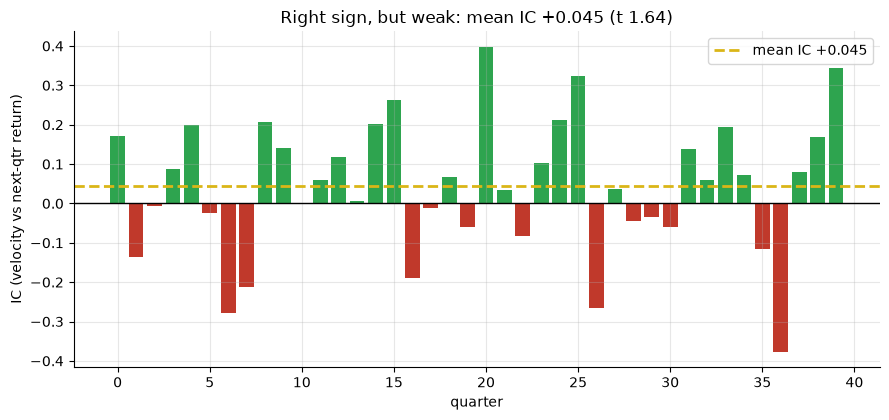

mean IC +0.045 | t 1.64 | positive in 60% of quarters


In [2]:
ics = st.period_ics(PANEL)
summ = st.ic_summary(PANEL)
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if v > 0 else RED for v in ics.values]
ax.bar(range(len(ics)), ics.values, color=cols, width=.8)
ax.axhline(0, c='k', lw=1)
ax.axhline(summ['mean_ic'], c=AMBER, lw=2, ls='--', label=f"mean IC {summ['mean_ic']:+.3f}")
ax.set_xlabel('quarter'); ax.set_ylabel('IC (velocity vs next-qtr return)')
ax.set_title(f"Right sign, but weak: mean IC {summ['mean_ic']:+.3f} (t {summ['t']:.2f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"mean IC {summ['mean_ic']:+.3f} | t {summ['t']:.2f} | positive in "
      f"{summ['hit']*100:.0f}% of quarters")

So the link is **there and pointing the right way** (positive in ~60% of quarters, mean IC **+0.045**) — but it's *small*, and small signals are easy to fake with luck. The *t*-score is **1.64**, under our bar of 2.

**Is it just luck?** Shuffle the velocity labels against the returns thousands of times and see how often pure noise beats what we saw.

In [3]:
p = st.placebo_pvalue(PANEL, n_perm=1500, seed=553)
obs = abs(st.ic_summary(PANEL)['mean_ic'])
print(f'observed |mean IC| = {obs:.3f}  ->  placebo p = {p:.3f}')
print('Not significant (p > 0.05): noise reproduces this too often.' if p > 0.05
      else 'Significant.')

observed |mean IC| = 0.045  ->  placebo p = 0.123
Not significant (p > 0.05): noise reproduces this too often.


> The placebo *p* is about **0.12** — noise reproduces a link this big more than 1 time in 10. We *cannot* rule out luck on this sample.

## 5 · The verdict

- **Signal — Weak.** Right sign, but IC-*t* **1.64** (below 2) and placebo *p* **0.12**; and it can *never* be 'Real' because there's no honest real tape to test it on.
- **Tradability — Mirage.** You can't reconstruct past GitHub velocity, so you can't actually build or backtest the signal — before you even get to the short-borrow cost.

## 6 · Could you actually trade it?

No — and for an unusual reason. Normally a signal dies at *costs*. This one dies *earlier*: **you can't get the data.** GitHub's public feeds show you the *current* state of the world. Repos get renamed, archived, deleted, or moved private; commit histories can be rewritten; the API is rate-limited. So the velocity a trader would have *seen* on some Tuesday in 2019 is largely unrecoverable — and any backtest built on today's snapshot is quietly contaminated by survivorship and look-ahead. Even if the nowcast were real, you couldn't honestly measure it, let alone the short-borrow you'd pay to bet against the laggards.

## 7 · Going further 🚪

- **The audited cousin.** [400 Patent-Intensity](../../400-patent-intensity/) uses *reported R&D / revenue* — data you *can* get point-in-time — and still only reaches a 'Weak' innovation premium.
- **Other firm-telemetry alt-data.** [392 Glassdoor-Sentiment](../../392-glassdoor-sentiment/) and [528 Labor-Hiring-Rate](../../528-labor-hiring-rate/) hit the same *point-in-time* wall.

*Think the nowcast is real? The honest test needs a **point-in-time GitHub archive** (e.g. the GH Archive on BigQuery, snapshotted daily) mapped to tickers with no survivorship holes. Fork this, build that tape, and show the IC clearing t = 2 out of sample.*